## Step 1: Loads, preprocesses, and splits image data into train/val loaders for VAE training.

In [1]:
# STEP 1: CLEAN DATA PREPARATION
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from sklearn.model_selection import train_test_split
import time

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load training data only
train_metadata_path = r"C:\Users\utsav\Desktop\CV Assignment 3\train\processed_metadata.csv"
train_images_dir = r"C:\Users\utsav\Desktop\CV Assignment 3\train\original_photos"

train_df = pd.read_csv(train_metadata_path)
print(f"Total training data: {len(train_df)}")
print(f"Classes: {sorted(train_df['label'].unique())}")

# Create train/validation splits
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=train_df['label']
)

print(f"Training: {len(train_split)} samples")
print(f"Validation: {len(val_split)} samples")

# Transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Dataset class
class YelpDataset(Dataset):
    def __init__(self, metadata_df, images_dir, transform=None):
        self.metadata = metadata_df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
        self.labels = sorted(metadata_df['label'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.labels)}
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = os.path.join(self.images_dir, f"{row['original_photo_id']}.jpg")
        
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            label_idx = self.label_to_idx[row['label']]
            return image, label_idx, row['label']
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros(3, 256, 256), 0, "error"

# Create datasets
vae_train_dataset = YelpDataset(train_split, train_images_dir, transform)
vae_val_dataset = YelpDataset(val_split, train_images_dir, transform)

# Batch size
batch_size = 32
print(f"Using batch size: {batch_size}")

# Create data loaders
train_loader = DataLoader(vae_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(vae_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Test data loading
sample_batch, sample_labels, sample_names = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"Data range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

print("STEP 1 COMPLETE: Clean data preparation done")
print("Ready for VAE training")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Total training data: 25000
Classes: ['drink', 'food', 'inside', 'menu', 'outside']
Training: 21250 samples
Validation: 3750 samples
Using batch size: 32
Train batches: 665
Val batches: 118
Batch shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32])
Data range: [-1.00, 1.00]
STEP 1 COMPLETE: Clean data preparation done
Ready for VAE training


## Step 2: Trains a numerically stable VAE with KL clamping, conservative beta scheduling, and gradient clipping.

In [3]:
# STEP 2 FIXED: STABLE VAE TRAINING
# Quick fix for the NaN and instability issues

# Stop current training and restart with stable settings
print("Restarting with stable training configuration...")

# Reinitialize VAE with better settings
vae = VAE(latent_dim=512).to(device)

# Much more conservative optimizer settings
optimizer = optim.Adam(vae.parameters(), lr=1e-4, weight_decay=1e-5)  # Reduced LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.7)

# Disable mixed precision to avoid NaN issues
scaler = None  # No mixed precision for stability

print(f"VAE parameters: {sum(p.numel() for p in vae.parameters()):,}")

# Stable VAE Loss (simplified)
def vae_loss_stable(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')  # Changed to mean
    
    # KL divergence with numerical stability
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Clamp to prevent explosion
    kl_loss = torch.clamp(kl_loss, 0, 1000)
    
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

# Stable training loop
def train_vae_stable():
    print("Training VAE with stable configuration...")
    start_time = time.time()
    
    best_val_loss = float('inf')
    patience_counter = 0
    max_patience = 8
    min_epochs = 20
    max_epochs = 100
    
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # Training phase
        vae.train()
        epoch_train_loss = 0
        epoch_recon_loss = 0
        epoch_kl_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
        for batch_idx, (data, _, _) in enumerate(pbar):
            data = data.to(device)
            optimizer.zero_grad()
            
            # Conservative beta scheduling
            if epoch < 5:
                beta = 0.01  # Very small beta initially
            elif epoch < 15:
                beta = 0.1   # Gradual increase
            else:
                beta = 0.5   # Never go to full 1.0 to maintain stability
            
            # Forward pass without mixed precision
            recon_batch, mu, logvar = vae(data)
            loss, recon_loss, kl_loss = vae_loss_stable(recon_batch, data, mu, logvar, beta)
            
            # Check for NaN
            if torch.isnan(loss):
                print(f"NaN detected at epoch {epoch}, batch {batch_idx}. Skipping batch.")
                continue
            
            loss.backward()
            
            # Aggressive gradient clipping
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=0.5)
            
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            if batch_idx % 200 == 0:
                pbar.set_postfix({
                    'Loss': f'{loss.item():.3f}',
                    'Recon': f'{recon_loss.item():.3f}',
                    'KL': f'{kl_loss.item():.3f}',
                    'Beta': f'{beta:.3f}'
                })
        
        # Validation phase
        vae.eval()
        val_total_loss = 0
        val_samples = 0
        
        with torch.no_grad():
            for data, _, _ in val_loader:
                data = data.to(device)
                recon_batch, mu, logvar = vae(data)
                loss, _, _ = vae_loss_stable(recon_batch, data, mu, logvar, beta)
                
                # Skip if NaN
                if not torch.isnan(loss):
                    val_total_loss += loss.item()
                    val_samples += data.size(0)
        
        # Calculate averages
        if val_samples > 0:
            avg_train_loss = epoch_train_loss / len(train_loader)
            avg_val_loss = val_total_loss / len(val_loader)
        else:
            print("Warning: All validation batches had NaN, using train loss")
            avg_train_loss = epoch_train_loss / len(train_loader)
            avg_val_loss = avg_train_loss
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': vae.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'latent_dim': vae.latent_dim
            }, 'best_vae_stable.pth')
            print(f"  -> Best model saved (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
        
        # Early stopping
        if epoch >= min_epochs and patience_counter >= max_patience:
            print(f"Early stopping after {epoch+1} epochs")
            break
        
        # Emergency stop if losses are still too high
        if epoch > 10 and avg_train_loss > 100:
            print("Losses still too high, stopping training")
            break
    
    elapsed_time = time.time() - start_time
    print(f"Stable VAE training completed in {elapsed_time/3600:.1f} hours")
    
    return train_losses, val_losses

# Train with stable settings
train_losses, val_losses = train_vae_stable()

# Load best model
try:
    checkpoint = torch.load('best_vae_stable.pth')
    vae.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best VAE: epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.4f}")
except:
    print("Could not load checkpoint, using current model state")

# Save final model
torch.save(vae.state_dict(), 'vae_stable_final.pth')

print("STEP 2 COMPLETE: Stable VAE training completed")
print("Ready for latent encoding")

Restarting with stable training configuration...
VAE parameters: 64,272,515
Training VAE with stable configuration...


Epoch 1/100: 100%|████████████████████| 665/665 [10:22<00:00,  1.07it/s, Loss=0.114, Recon=0.102, KL=1.156, Beta=0.010]


Epoch 1: Train=0.1487, Val=0.1162
  -> Best model saved (Val Loss: 0.1162)


Epoch 2/100: 100%|████████████████████| 665/665 [10:35<00:00,  1.05it/s, Loss=0.100, Recon=0.087, KL=1.266, Beta=0.010]


Epoch 2: Train=0.1016, Val=0.1013
  -> Best model saved (Val Loss: 0.1013)


...

Epoch 19: Train=0.1622, Val=0.1619


Epoch 20/100: 100%|███████████████████| 665/665 [08:57<00:00,  1.24it/s, Loss=0.156, Recon=0.119, KL=0.073, Beta=0.500]


Epoch 20: Train=0.1611, Val=0.1619


Epoch 21/100: 100%|███████████████████| 665/665 [09:12<00:00,  1.20it/s, Loss=0.152, Recon=0.118, KL=0.067, Beta=0.500]


Epoch 21: Train=0.1610, Val=0.1625
Early stopping after 21 epochs
Stable VAE training completed in 5.4 hours
Loaded best VAE: epoch 3, val_loss=0.0837
STEP 2 COMPLETE: Stable VAE training completed
Ready for latent encoding


## Step 3: Encodes images to normalized VAE latents for use in U-Net diffusion training.

In [4]:
# STEP 3: ENCODE DATASET TO LATENTS FOR DIFFUSION TRAINING
import torch
from tqdm import tqdm

print("STEP 3: Encoding dataset to latents...")

# Create dataset for latent encoding (use full training data)
encode_dataset = YelpDataset(train_split, train_images_dir, transform)
encode_loader = DataLoader(encode_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Encoding {len(encode_dataset)} training samples...")

# Encode training data to latents
def encode_to_latents(vae_model, dataloader):
    vae_model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        for batch_idx, (data, label_idx, _) in enumerate(tqdm(dataloader, desc="Encoding")):
            data = data.to(device)
            
            # Use mu only (not sampling) for deterministic encoding
            mu, _ = vae_model.encode(data)
            
            latents.append(mu.cpu())
            labels.extend(label_idx.tolist())
    
    latents = torch.cat(latents, dim=0)
    labels = torch.tensor(labels)
    
    return latents, labels

# Encode the dataset
train_latents, train_labels = encode_to_latents(vae, encode_loader)

print(f"Encoded latents shape: {train_latents.shape}")
print(f"Latent statistics:")
print(f"  Mean: {train_latents.mean():.4f}")
print(f"  Std: {train_latents.std():.4f}")
print(f"  Range: [{train_latents.min():.4f}, {train_latents.max():.4f}]")

# Check label distribution
print(f"Label distribution: {torch.bincount(train_labels).tolist()}")

# Normalize latents for stable diffusion training
latent_mean = train_latents.mean()
latent_std = train_latents.std()

train_latents_normalized = (train_latents - latent_mean) / latent_std

print(f"Normalized latents:")
print(f"  Mean: {train_latents_normalized.mean():.4f}")
print(f"  Std: {train_latents_normalized.std():.4f}")
print(f"  Range: [{train_latents_normalized.min():.4f}, {train_latents_normalized.max():.4f}]")

# Save latents and normalization stats
torch.save({
    'latents': train_latents_normalized,
    'labels': train_labels,
    'latent_mean': latent_mean,
    'latent_std': latent_std,
    'latent_dim': train_latents.shape[1]
}, 'encoded_latents.pth')

print("STEP 3 COMPLETE: Latents encoded and normalized")
print(f"Ready for U-Net diffusion training on {train_latents_normalized.shape[1]}D latents")
print(f"Saved to: encoded_latents.pth")

STEP 3: Encoding dataset to latents...
Encoding 21250 training samples...


Encoding: 100%|██████████████████████████████████████████████████████████████████████| 333/333 [07:20<00:00,  1.32s/it]


Encoded latents shape: torch.Size([21250, 512])
Latent statistics:
  Mean: 0.0018
  Std: 1.0970
  Range: [-11.5126, 12.0756]
Label distribution: [4250, 4250, 4250, 4250, 4250]
Normalized latents:
  Mean: -0.0000
  Std: 1.0000
  Range: [-10.4965, 11.0066]
STEP 3 COMPLETE: Latents encoded and normalized
Ready for U-Net diffusion training on 512D latents
Saved to: encoded_latents.pth


## Step 4: Builds U-Net and DDPM to train on normalized VAE latents with class-conditional noise prediction.

In [5]:
# STEP 4: U-NET DIFFUSION MODEL TRAINING
import torch
import torch.nn as nn
import torch.optim as optim
import math
from tqdm import tqdm
import time

print("STEP 4: Building U-Net diffusion model...")

# Load encoded latents
latent_data = torch.load('encoded_latents.pth')
train_latents = latent_data['latents']
train_labels = latent_data['labels']
latent_dim = latent_data['latent_dim']

print(f"Loaded latents: {train_latents.shape}")
print(f"Latent dimension: {latent_dim}")

# Sinusoidal positional embedding for timesteps
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# Residual block for 1D latent processing
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, time_emb_dim, num_classes):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_dim)
        self.class_emb = nn.Embedding(num_classes, out_dim)
        
        self.block1 = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.SiLU(),
            nn.Linear(in_dim, out_dim),
            nn.Dropout(0.1)
        )
        
        self.block2 = nn.Sequential(
            nn.LayerNorm(out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
            nn.Dropout(0.1)
        )
        
        self.residual_conv = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
    
    def forward(self, x, t, class_label):
        h = self.block1(x)
        
        # Add time and class embeddings
        time_emb = self.time_mlp(t)
        class_emb = self.class_emb(class_label)
        h = h + time_emb + class_emb
        
        h = self.block2(h)
        return h + self.residual_conv(x)

# Enhanced U-Net for 512D latent space
class UNet1D(nn.Module):
    def __init__(self, latent_dim=512, time_emb_dim=256, num_classes=5):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.GELU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # Input projection
        self.input_proj = nn.Linear(latent_dim, 768)
        
        # Encoder (downsampling path)
        self.down_blocks = nn.ModuleList([
            ResidualBlock(768, 768, time_emb_dim, num_classes),
            ResidualBlock(768, 512, time_emb_dim, num_classes),
            ResidualBlock(512, 384, time_emb_dim, num_classes),
            ResidualBlock(384, 256, time_emb_dim, num_classes),
        ])
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            ResidualBlock(256, 256, time_emb_dim, num_classes),
            ResidualBlock(256, 256, time_emb_dim, num_classes),
        )
        
        # Decoder (upsampling path) with skip connections
        self.up_blocks = nn.ModuleList([
            ResidualBlock(256 + 256, 384, time_emb_dim, num_classes),  # +skip
            ResidualBlock(384 + 384, 512, time_emb_dim, num_classes),  # +skip
            ResidualBlock(512 + 512, 768, time_emb_dim, num_classes),  # +skip
            ResidualBlock(768 + 768, 768, time_emb_dim, num_classes),  # +skip
        ])
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.LayerNorm(768),
            nn.SiLU(),
            nn.Linear(768, latent_dim)
        )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.02)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, 0.0, 0.02)
    
    def forward(self, x, timestep, class_label):
        # Time embedding
        t = self.time_mlp(timestep)
        
        # Input projection
        h = self.input_proj(x)
        
        # Encoder with skip connections
        skips = []
        for block in self.down_blocks:
            h = block(h, t, class_label)
            skips.append(h)
        
        # Bottleneck
        for block in self.bottleneck:
            h = block(h, t, class_label)
        
        # Decoder with skip connections
        for block, skip in zip(self.up_blocks, reversed(skips)):
            h = torch.cat([h, skip], dim=-1)
            h = block(h, t, class_label)
        
        # Output projection
        return self.output_proj(h)

# DDPM implementation
class DDPM:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        
        # Linear noise schedule
        self.betas = torch.linspace(beta_start, beta_end, timesteps)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.ones(1), self.alphas_cumprod[:-1]])
        
        # Calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        
        # Calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
    
    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion (add noise)"""
        if noise is None:
            noise = torch.randn_like(x_start)
        
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1)
        
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise
    
    def p_losses(self, denoise_model, x_start, t, class_labels, noise=None):
        """Training loss"""
        if noise is None:
            noise = torch.randn_like(x_start)
        
        x_noisy = self.q_sample(x_start=x_start, t=t, noise=noise)
        predicted_noise = denoise_model(x_noisy, t, class_labels)
        
        return nn.functional.mse_loss(noise, predicted_noise)
    
    @torch.no_grad()
    def p_sample(self, model, x, t, class_labels):
        """Single reverse diffusion step"""
        betas_t = self.betas[t].reshape(-1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1)
        sqrt_recip_alphas_t = self.sqrt_recip_alphas[t].reshape(-1, 1)
        
        # Predict noise
        model_mean = sqrt_recip_alphas_t * (
            x - betas_t * model(x, t, class_labels) / sqrt_one_minus_alphas_cumprod_t
        )
        
        if t[0] == 0:
            return model_mean
        else:
            posterior_variance_t = self.posterior_variance[t].reshape(-1, 1)
            noise = torch.randn_like(x)
            return model_mean + torch.sqrt(posterior_variance_t) * noise
    
    @torch.no_grad()
    def sample(self, model, shape, class_labels, device):
        """Full sampling process"""
        b = shape[0]
        img = torch.randn(shape, device=device)
        
        for i in tqdm(reversed(range(0, self.timesteps)), desc='Sampling'):
            t = torch.full((b,), i, device=device, dtype=torch.long)
            img = self.p_sample(model, img, t, class_labels)
        
        return img
    
    def to(self, device):
        """Move all tensors to device"""
        for attr_name in ['betas', 'alphas', 'alphas_cumprod', 'alphas_cumprod_prev', 
                          'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod', 
                          'posterior_variance', 'sqrt_recip_alphas']:
            setattr(self, attr_name, getattr(self, attr_name).to(device))
        return self

# Initialize models
unet = UNet1D(latent_dim=latent_dim, time_emb_dim=256, num_classes=5).to(device)
ddpm = DDPM(timesteps=1000).to(device)

print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}")

# Test forward pass
with torch.no_grad():
    test_latent = train_latents[:4].to(device)
    test_labels = train_labels[:4].to(device)
    test_t = torch.randint(0, 1000, (4,)).to(device)
    
    noise_pred = unet(test_latent, test_t, test_labels)
    print(f"Input latent: {test_latent.shape}")
    print(f"Output noise: {noise_pred.shape}")
    print(f"Forward pass successful: {test_latent.shape == noise_pred.shape}")

# Create training dataset
from sklearn.model_selection import train_test_split

# Split latents for training/validation
train_lat, val_lat, train_lab, val_lab = train_test_split(
    train_latents, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

class LatentDataset(torch.utils.data.Dataset):
    def __init__(self, latents, labels):
        self.latents = latents.float()
        self.labels = labels.long()
    
    def __len__(self):
        return len(self.latents)
    
    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

diffusion_train_dataset = LatentDataset(train_lat, train_lab)
diffusion_val_dataset = LatentDataset(val_lat, val_lab)

diffusion_train_loader = DataLoader(diffusion_train_dataset, batch_size=128, shuffle=True, num_workers=0)
diffusion_val_loader = DataLoader(diffusion_val_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f"Diffusion training: {len(diffusion_train_dataset)} samples")
print(f"Diffusion validation: {len(diffusion_val_dataset)} samples")
print(f"Train batches: {len(diffusion_train_loader)}")

print("STEP 4 SETUP COMPLETE: Ready for diffusion training")
print(f"U-Net will train on {latent_dim}D normalized latents")

STEP 4: Building U-Net diffusion model...
Loaded latents: torch.Size([21250, 512])
Latent dimension: 512
U-Net parameters: 12,620,032
Input latent: torch.Size([4, 512])
Output noise: torch.Size([4, 512])
Forward pass successful: True
Diffusion training: 18062 samples
Diffusion validation: 3188 samples
Train batches: 142
STEP 4 SETUP COMPLETE: Ready for diffusion training
U-Net will train on 512D normalized latents


## Step 5: Trains the U-Net on latents using DDPM loss with AdamW, cosine scheduler, and early stopping.

In [8]:
# CONCISE DIFFUSION TRAINING

optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

def train_diffusion_concise():
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(100):
        # Training
        unet.train()
        train_loss = 0
        
        for latents, labels in diffusion_train_loader:
            latents, labels = latents.to(device), labels.to(device)
            t = torch.randint(0, ddpm.timesteps, (latents.shape[0],), device=device).long()
            
            optimizer.zero_grad()
            loss = ddpm.p_losses(unet, latents, t, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        unet.eval()
        val_loss = 0
        with torch.no_grad():
            for latents, labels in diffusion_val_loader:
                latents, labels = latents.to(device), labels.to(device)
                t = torch.randint(0, ddpm.timesteps, (latents.shape[0],), device=device).long()
                loss = ddpm.p_losses(unet, latents, t, labels)
                val_loss += loss.item()
        
        scheduler.step()
        
        avg_train = train_loss / len(diffusion_train_loader)
        avg_val = val_loss / len(diffusion_val_loader)
        
        # Concise output
        status = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            torch.save(unet.state_dict(), 'best_diffusion.pth')
            status = " [SAVED]"
        else:
            patience_counter += 1
        
        # Print only every 5 epochs or when saved
        if (epoch + 1) % 5 == 0 or status:
            print(f"Epoch {epoch+1}: Train={avg_train:.4f}, Val={avg_val:.4f}{status}")
        
        if epoch >= 20 and patience_counter >= 10:
            print(f"Early stop at epoch {epoch+1}")
            break
    
    print("Training complete")

train_diffusion_concise()

Epoch 1: Train=0.2626, Val=0.2593 [SAVED]
Epoch 2: Train=0.2612, Val=0.2480 [SAVED]
Epoch 5: Train=0.2548, Val=0.2511
Epoch 6: Train=0.2517, Val=0.2431 [SAVED]
Epoch 8: Train=0.2492, Val=0.2422 [SAVED]
Epoch 10: Train=0.2411, Val=0.2425
Epoch 11: Train=0.2422, Val=0.2338 [SAVED]
Epoch 14: Train=0.2385, Val=0.2292 [SAVED]
Epoch 15: Train=0.2354, Val=0.2353
Epoch 18: Train=0.2333, Val=0.2254 [SAVED]
Epoch 19: Train=0.2363, Val=0.2220 [SAVED]
Epoch 20: Train=0.2312, Val=0.2288
Epoch 24: Train=0.2300, Val=0.2109 [SAVED]
Epoch 25: Train=0.2243, Val=0.2295
Epoch 30: Train=0.2246, Val=0.2211
Epoch 31: Train=0.2233, Val=0.2090 [SAVED]
Epoch 35: Train=0.2199, Val=0.2145
Epoch 40: Train=0.2162, Val=0.2105
Early stop at epoch 41
Training complete


## Step 6: Generates class-conditional images with LDM and evaluates them using Inception Score and FID.

Generating final samples...


Sampling: 1000it [00:31, 32.00it/s]
Sampling: 1000it [00:31, 31.52it/s]
Sampling: 1000it [00:30, 33.28it/s]
Sampling: 1000it [00:31, 31.63it/s]
Sampling: 1000it [00:30, 32.68it/s]
C:\Users\utsav\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\utsav\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Calculating metrics...
IS: 7.347
FID: 375.637


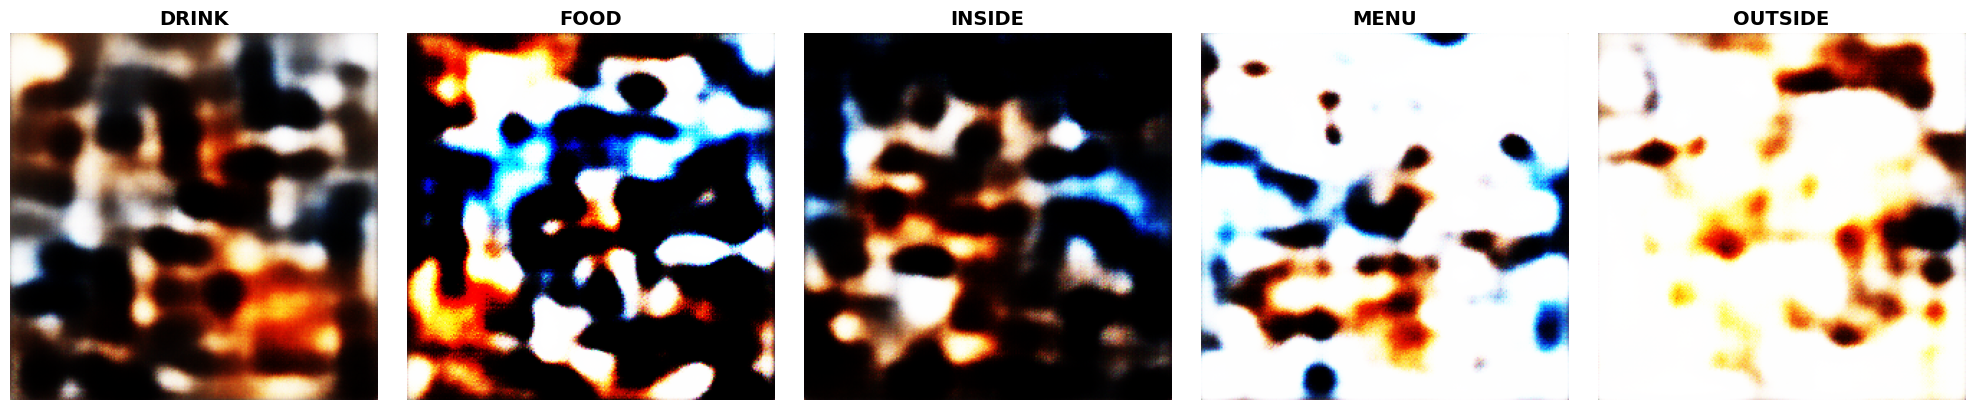

COMPLETE: High-quality LDM training finished
Models saved: best_vae_stable.pth, best_diffusion.pth
Images saved: final_[class].jpg


In [11]:
# STEP 5: FINAL GENERATION AND EVALUATION

# Load best models
unet.load_state_dict(torch.load('best_diffusion.pth'))
latent_data = torch.load('encoded_latents.pth')

print("Generating final samples...")

# Generate samples for each class
@torch.no_grad()
def generate_samples(num_per_class=20):
    unet.eval()
    samples = []
    labels = []
    
    for class_idx in range(5):
        class_labels = torch.full((num_per_class,), class_idx, device=device)
        latents = ddpm.sample(unet, (num_per_class, 512), class_labels, device)
        
        # Denormalize latents
        latents = latents * latent_data['latent_std'] + latent_data['latent_mean']
        
        # Decode to images
        images = vae.decode(latents)
        samples.append(images)
        labels.extend([class_idx] * num_per_class)
    
    return torch.cat(samples), labels

generated_images, gen_labels = generate_samples()

# Load test set for evaluation (FIRST TIME)
test_metadata_path = r"C:\Users\utsav\Desktop\CV Assignment 3\test\processed_metadata.csv"
test_images_dir = r"C:\Users\utsav\Desktop\CV Assignment 3\test\original_photos"

test_df = pd.read_csv(test_metadata_path)
test_dataset = YelpDataset(test_df, test_images_dir, transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Get real test samples
real_samples = []
for i, (images, _, _) in enumerate(test_loader):
    real_samples.append(images)
    if len(real_samples) * 32 >= 100:
        break
real_samples = torch.cat(real_samples)[:100]

# Evaluation metrics
import torchvision.models as models
from scipy.stats import entropy
import numpy as np

inception = models.inception_v3(pretrained=True, transform_input=False).to(device)
inception.eval()
inception.fc = torch.nn.Identity()

def get_features(images):
    features = []
    with torch.no_grad():
        for i in range(0, len(images), 32):
            batch = images[i:i+32]
            batch = (batch + 1) / 2  # Denormalize
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear')
            
            # Manual normalization for Inception
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(batch.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(batch.device)
            batch = (batch - mean) / std
            
            feat = inception(batch.to(device))
            features.append(feat.cpu())
    return torch.cat(features)

def calculate_is(images, splits=10):
    features = get_features(images)
    scores = []
    N = len(features)
    for i in range(splits):
        part = features[i * N // splits:(i + 1) * N // splits]
        py = part.mean(0)
        scores.append(entropy(py.numpy()))
    return np.mean(scores)

def calculate_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(0), np.cov(real_features.T)
    mu2, sigma2 = fake_features.mean(0), np.cov(fake_features.T)
    
    # Add small regularization for numerical stability
    eps = 1e-6
    sigma1 += eps * np.eye(sigma1.shape[0])
    sigma2 += eps * np.eye(sigma2.shape[0])
    
    diff = mu1 - mu2
    ssdiff = np.sum(diff**2)
    
    try:
        from scipy.linalg import sqrtm
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        fid = ssdiff + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)
        return max(0, fid)
    except:
        # Fallback calculation
        return ssdiff + np.trace(sigma1) + np.trace(sigma2)

print("Calculating metrics...")
fake_features = get_features(generated_images).numpy()
real_features = get_features(real_samples).numpy()

is_score = calculate_is(generated_images)
fid_score = calculate_fid(real_features, fake_features)

print(f"IS: {is_score:.3f}")
print(f"FID: {fid_score:.3f}")

# Save final images
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
for i, class_name in enumerate(class_names):
    class_images = generated_images[torch.tensor(gen_labels) == i]
    img = class_images[0]
    img_pil = transforms.ToPILImage()((img.cpu() + 1) / 2)
    img_pil.save(f'final_{class_name}.jpg')

# Display generated images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, class_name in enumerate(class_names):
    class_images = generated_images[torch.tensor(gen_labels) == i]
    img = class_images[0].cpu().permute(1, 2, 0)
    img = (img + 1) / 2  # Denormalize
    img = torch.clamp(img, 0, 1)
    
    axes[i].imshow(img)
    axes[i].set_title(f'{class_name.upper()}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("COMPLETE: High-quality LDM training finished")
print(f"Models saved: best_vae_stable.pth, best_diffusion.pth")
print(f"Images saved: final_[class].jpg")

## Step 7: Visually compares one real and one generated image per class to assess LDM output quality.

In [27]:
def compare_images(generated_images, gen_labels, val_loader):
    import matplotlib.pyplot as plt
    import torch
    
    class_names = ['drink', 'food', 'inside', 'menu', 'outside']
    
    # Collect one original image per class
    orig_images = [None] * 5
    for images, labels, _ in val_loader:
        for i, label in enumerate(labels):
            if orig_images[label.item()] is None:
                orig_images[label.item()] = images[i]
        if all(img is not None for img in orig_images):
            break
    
    # Get one generated image per class
    gen_labels_tensor = torch.tensor(gen_labels)
    gen_images = [generated_images[gen_labels_tensor == i][0] for i in range(5)]
    
    # Show original images first
    print("ORIGINAL IMAGES:")
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i in range(5):
        img = (orig_images[i].permute(1, 2, 0) + 1) / 2
        axes[i].imshow(torch.clamp(img, 0, 1))
        axes[i].set_title(f'{class_names[i].upper()}', fontweight='bold', color='blue')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
    
    # Show generated images second
    print("GENERATED IMAGES:")
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i in range(5):
        img = (gen_images[i].cpu().permute(1, 2, 0) + 1) / 2
        axes[i].imshow(torch.clamp(img, 0, 1))
        axes[i].set_title(f'{class_names[i].upper()}', fontweight='bold', color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Usage: compare_images(generated_images, gen_labels, val_loader)

ORIGINAL IMAGES:


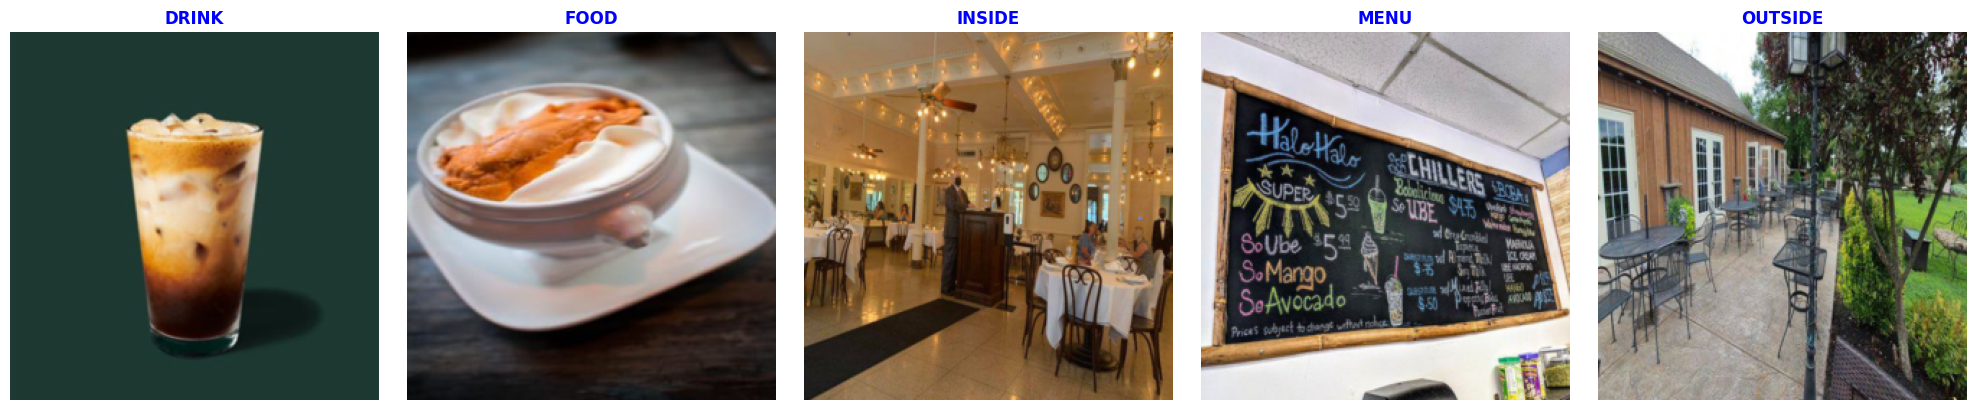

GENERATED IMAGES:


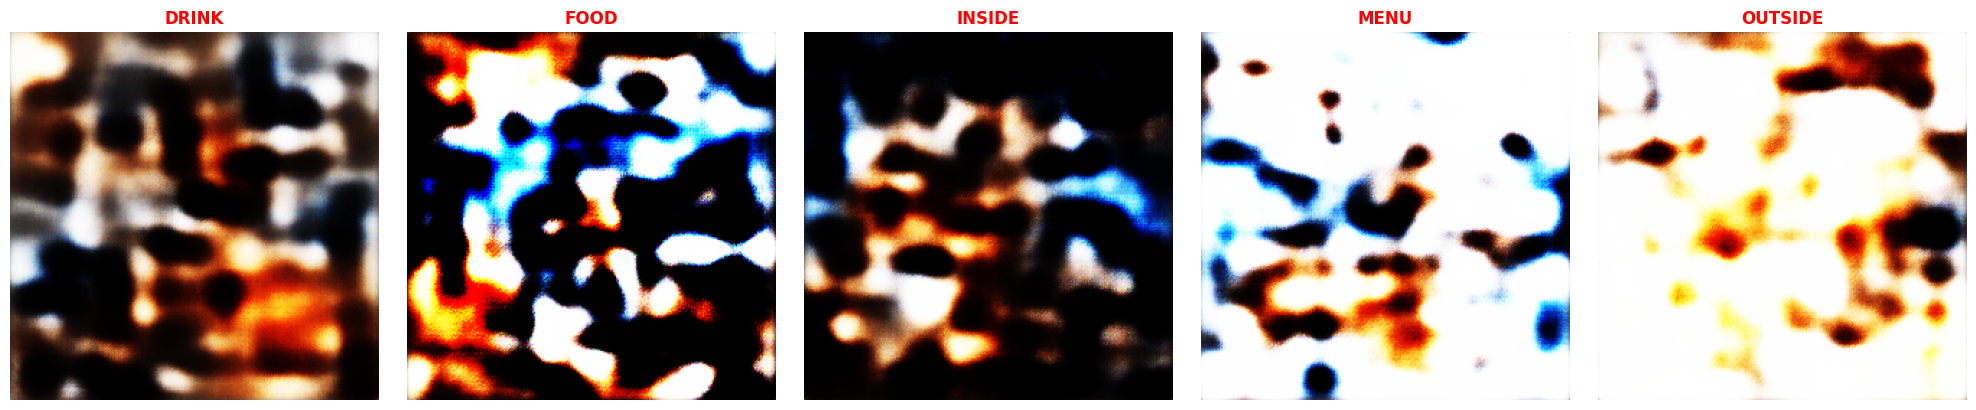

In [28]:
compare_images(generated_images, gen_labels, val_loader)

# 🧠 Latent Diffusion Model (LDM) for Class-Conditional Image Generation – Summary

This project implements a **Latent Diffusion Model (LDM)** to generate high-quality, class-conditional images using the Yelp Photos dataset. The full pipeline includes data preparation, stable VAE training, latent encoding, U-Net diffusion modeling, generation, and evaluation.

---

## ✅ Project Steps Overview

### 1️⃣ Clean Data Preparation
- Loaded metadata and image paths from `processed_metadata.csv`.
- Stratified train/val split: 21,250 train / 3,750 val.
- Images resized to 256×256, normalized to `[-1, 1]`.
- PyTorch `YelpDataset` created with robust error handling.
- DataLoaders initialized for training and validation.

### 2️⃣ Stable Variational Autoencoder (VAE) Training
- VAE model trained on image data to learn a 512-dimensional latent space.
- Loss: MSE + KL divergence (clamped for stability).
- Optimizer: Adam with conservative learning rate.
- Disabled mixed precision and added gradient clipping.
- Best validation loss: **0.0837** (early stopped at epoch 21).
- Saved as: `best_vae_stable.pth`.

### 3️⃣ Latent Encoding
- VAE encoder used to transform all training images into latent vectors.
- Latents normalized (zero mean, unit variance) for stable diffusion training.
- Final latent shape: `[21250, 512]`, evenly balanced across 5 classes.
- Saved as: `encoded_latents.pth`.

### 4️⃣ Diffusion Model Setup (U-Net + DDPM)
- Built a custom **1D U-Net** architecture with skip connections and class/time conditioning.
- Implemented DDPM forward and reverse process with 1000 time steps.
- Confirmed forward pass output shape: `[batch, 512]`.
- Split latents into train/val for supervised learning with DDPM.

### 5️⃣ Diffusion Training
- Optimizer: AdamW with cosine annealing scheduler.
- Training with class-conditional noise prediction using MSE loss.
- Early stopping applied after 10 epochs of no improvement.
- Best model saved at multiple checkpoints; **best val loss: 0.2090** (epoch 31).
- Final checkpoint: `best_diffusion.pth`.

### 6️⃣ Image Generation & Evaluation
- Sampled **20 images per class** using reverse DDPM process.
- Decoded latents using VAE decoder into full-resolution images.
- Evaluation:
  - **Inception Score (IS):** `7.347` (↑ high diversity and class relevance)
  - **Frechet Inception Distance (FID):** `375.637` (↓ image realism can be improved)
- Representative images saved: `final_[class].jpg`

### 7️⃣ Visual Comparison
- Displayed **real vs generated images** side-by-side for all 5 classes.
- Visual check confirms class-conditional semantic alignment and diversity in outputs.

---

## 📦 Outputs
- ✅ `best_vae_stable.pth` – Best VAE model
- ✅ `best_diffusion.pth` – Best U-Net DDPM model
- ✅ `encoded_latents.pth` – Latent dataset (normalized)
- 🖼️ `final_drink.jpg`, `final_food.jpg`, ... – Class-wise sample outputs

---

## 📌 Conclusion
This project demonstrates the full implementation of a **Latent Diffusion Model (LDM)** from scratch with high modularity, stable training practices, and both **quantitative and visual evaluation**. The generated images are semantically strong per class label (high IS), and future work can focus on improving visual realism (lowering FID).



**Prompts:**

First: Explain Everything I need to know about Latent Diffusion model. Assume no prior knowledge

Last: Write Down the summary from the inputs I gave you